In [1]:
import numpy as np
import params
from basis import *
from matplotlib import pyplot as plt

import matplotlib.ticker as ticker


In [2]:
def remake_cases(bog,allo):
    cases=[]
    for (b,a) in zip(bog,allo):
        if np.isnan(a):
            void,cs = params.create_cases(b,a)
        else:
            cs,void = params.create_cases(b,a)
        cases.append(cs)
        
    return cases

In [3]:
p_steady = np.loadtxt('fixed_steady/steady.csv')
bog,allo = np.loadtxt('fixed_steady/params.csv').T
cases = remake_cases(bog,allo)

In [4]:
allo.shape

(238,)

In [5]:

S_steady  = [   expected(*marginalize(p_st, case.states, 3) ) for p_st,case in zip(p_steady,cases)]
MI_steady = [mutual_info(*marginalize(p_st, case.states, [0,1]) ) for p_st,case in zip(p_steady,cases)]

In [6]:
bog_list = bog.reshape(-1,(bog!=bog[0]).argmax())[:,0]
allo = allo.reshape((bog_list.size,-1))
S_steady = np.array(S_steady).reshape((bog_list.size,-1))
MI_steady = np.array(MI_steady).reshape((bog_list.size,-1))

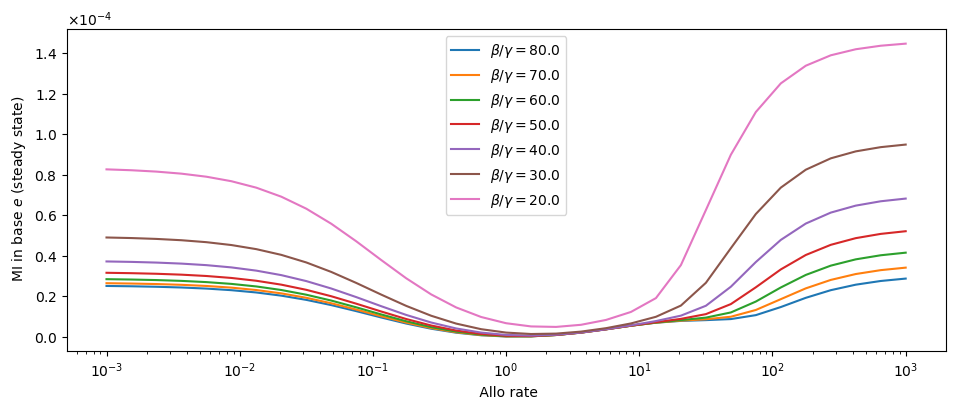

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))


[ax.plot(al[:-1],MI[:-1],label=r'$\beta / \gamma ={}$'.format(bog)) for al,MI,bog in zip(allo,MI_steady,bog_list) ]
#[ax.scatter(al[:-1],MI[:-1]) for al,MI,bog in zip(allo,MI_steady,bog_list) ]


plt.xlabel(r' Allo rate')
plt.xscale('log')

ax.set_ylabel(' MI in base $e$ (steady state)')
plt.tight_layout()

ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()

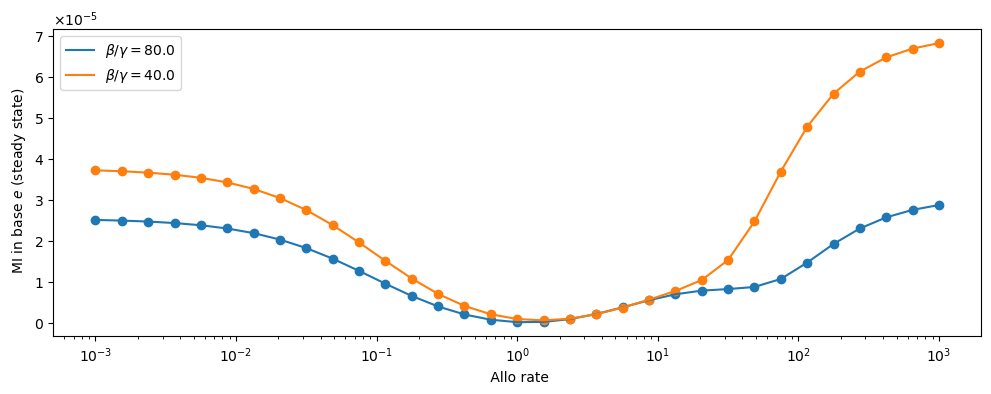

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ind = np.logical_or(bog_list==40,bog_list==80)

[ax.plot(al[:-1],MI[:-1],label=r'$\beta / \gamma ={}$'.format(bog)) for al,MI,bog in zip(allo[ind],MI_steady[ind],bog_list[ind]) ]
[ax.scatter(al[:-1],MI[:-1]) for al,MI,bog in zip(allo[ind],MI_steady[ind],bog_list[ind]) ]


plt.xlabel(r' Allo rate')
plt.xscale('log')

ax.set_ylabel(' MI in base $e$ (steady state)')
plt.tight_layout()

ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()

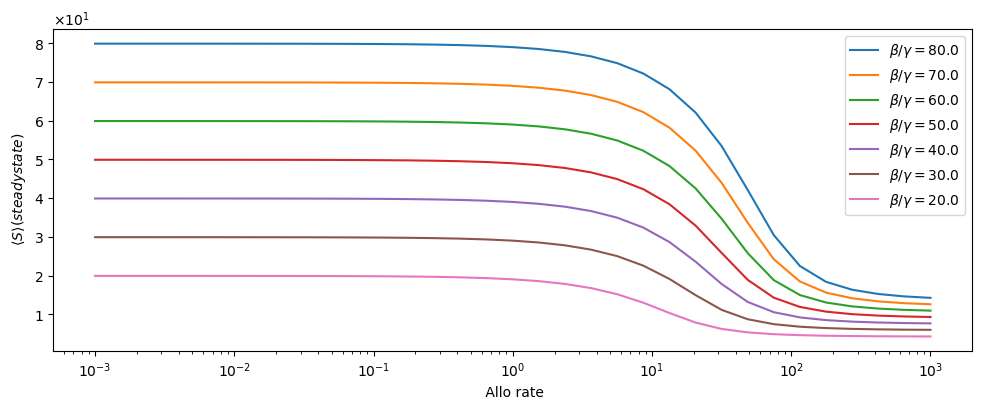

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))


[ax.plot(al[:-1],S[:-1],label=r'$\beta / \gamma ={}$'.format(bog)) for al,S,bog in zip(allo,S_steady,bog_list) ]
#[ax.scatter(al[:-1],S[:-1]) for al,S,bog in zip(allo,S_steady,bog_list) ]


plt.xlabel(r' Allo rate')
plt.xscale('log')
ax.set_ylabel(r' $\langle S \rangle (steady state)$')
plt.tight_layout()

ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()

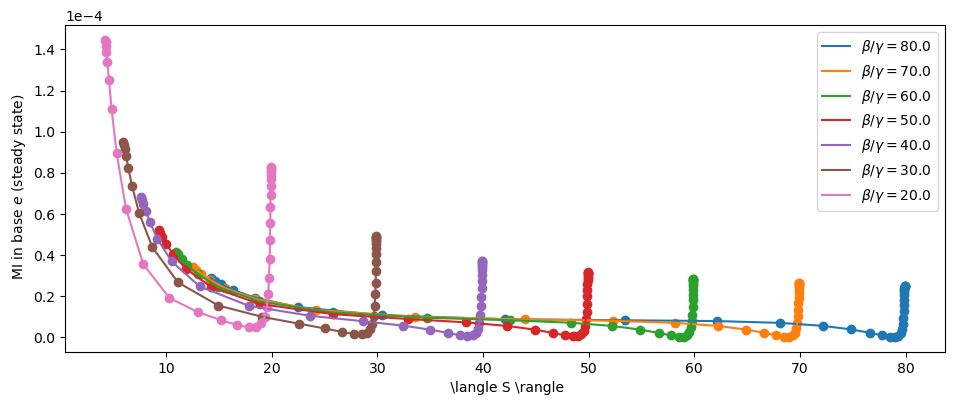

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 4))


[ax.plot(S[:-1],MI[:-1],label=r'$\beta / \gamma ={}$'.format(bog)) for S,MI,bog in zip(S_steady,MI_steady,bog_list) ]
[ax.scatter(S[:-1],MI[:-1]) for S,MI,bog in zip(S_steady,MI_steady,bog_list) ]


plt.xlabel(r' \langle S \rangle')
#plt.xscale('log')
ax.set_ylabel(' MI in base $e$ (steady state)')
plt.tight_layout()

#ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
plt.legend()